# Ljung-Box 检验
白噪声检验  
George E.P. Box 与 David A. Pierce 提出 Box-Pierce 检验  
Greta M. Ljung 与 George E.P. Box 在 Box-Pierce 的基础上提出 Ljung-Box 检验  
《On a Measure of Lack of Fit in Time Series Models》（1978）

In [1]:
import pandas as pd

df = pd.read_csv('sales_data.csv', parse_dates=['Date'])
ts = df[(df["Store ID"] == "S001") & (df["Product ID"] == "P0001")].set_index("Date")["Units Sold"]

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(ts)
print(lb_result)

       lb_stat     lb_pvalue
1    11.655828  6.400172e-04
2    43.407876  3.750588e-10
3    63.046014  1.312903e-13
4    82.110940  6.218109e-17
5    94.182271  8.873829e-19
6   110.629859  1.504476e-21
7   129.381034  8.465167e-25
8   138.630915  4.570318e-26
9   150.631068  6.526954e-28
10  162.527060  9.743314e-30


In [12]:
# 显著性水平
alpha = 0.05

# 判断是否为白噪声
if (lb_result['lb_pvalue'] > alpha).all():
    print("序列可能是白噪声（无法拒绝原假设）")
else:
    print("序列不是白噪声（存在显著自相关）")

序列不是白噪声（存在显著自相关）


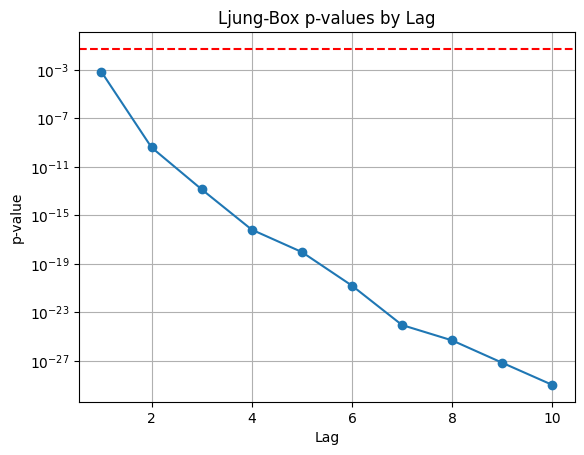

In [10]:
import matplotlib.pyplot as plt

lags = range(1, 11)
p_values = [6.400172e-04, 3.750588e-10, 1.312903e-13, 6.218109e-17,
            8.873829e-19, 1.504476e-21, 8.465167e-25, 4.570318e-26,
            6.526954e-28, 9.743314e-30]

plt.plot(lags, p_values, marker='o')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Ljung-Box p-values by Lag")
plt.xlabel("Lag")
plt.ylabel("p-value")
plt.yscale("log")
plt.grid(True)
plt.show()